In [7]:
%% Code to understand what adding heterogeneity into eigenmodes actually does
clear
clc

% Load config file
config = jsondecode(fileread("/fs04/kg98/vbarnes/HeteroModes/scripts/config.json"));
atlas = config.atlas;
space = config.space;
den = config.den;
surf = config.surf;
hemi = config.hemi;
nModes = config.n_modes;
realHeteroMaps = config.hetero_maps;
emodeDir = config.emode_dir;
surfDir = config.surface_dir;
projDir = '/fs04/kg98/vbarnes/HeteroModes';

heteroLabel = "MLcoords"; % only plot one hetero map per figure
scale = ["cmean"];
alphaVals = ["0.1", "1.0"];
% alphaVals = ["0.1", "0.5", "1.0", "1.5", "2.0", "2.5"];

% Set text for output fileneames
heteroParams = {heteroLabel, scale, alphaVals};
text = cell(1, numel(heteroParams));
for ii = 1:numel(heteroParams)
    if size(heteroParams{ii}, 2) > 1
        text{ii} = strjoin(heteroParams{ii}, '-');
    else
        text{ii} = heteroParams{ii};
    end
end
heteroText = text{1};
scaleText = text{2};
alphaText = text{3};

% TODO: set list of basis set filenames
nBasisSets = length(alphaVals);
basisSetLabels = alphaVals;

% Load Yeo surface file
[vertices, faces] = read_vtk(sprintf('%s/atlas-yeo_space-%s_den-%s_surf-%s_hemi-%s_surface.vtk', ...
    surfDir, space, den, surf, hemi));
surface.vertices = vertices';
surface.faces = faces';
% Load cortex mask
medialMask = dlmread(sprintf('%s/atlas-yeo_space-%s_den-%s_hemi-%s_medialMask.txt', surfDir, space, ...
    den, hemi));
cortexInds = find(medialMask);

geomDesc = 'hetero-%s_atlas-%s_space-%s_den-%s_surf-%s_hemi-%s_n-%i_maskMed-True';
% Load geometric eigenmodes and eigenvalues
geomModes = dlmread(fullfile(emodeDir, sprintf(geomDesc, "None", atlas, space, den, surf, hemi, nModes) ...
    + "_emodes.txt"));
geomEvals = dlmread(fullfile(emodeDir, sprintf(geomDesc, "None", atlas, space, den, surf, hemi, nModes) ...
    + "_evals.txt"));

% Load propagation speed maps (C)
heteroDesc = 'hetero-%s_atlas-%s_space-%s_den-%s_surf-%s_hemi-%s_n-%i_scale-%s_alpha-%s_maskMed-True';
cmaps = zeros(size(geomModes, 1), nBasisSets);
for ii=1:nBasisSets
    cmaps(:, ii) = dlmread(fullfile(emodeDir, "cmaps", sprintf(heteroDesc, heteroLabel, atlas, ...
        space, den, surf, hemi, nModes, scale, alphaVals(ii)) + "_cmap.txt")); 
end
% Find min and max values in cmaps for plotting on using same x axis
cmapLimsGlobal = [round(min(cmaps(cortexInds, :), [], "all")), round(max(cmaps(cortexInds, :), [], "all"))];

% Load heterogeneous eigenmodes and eigenvalues
heteroModes = zeros([size(geomModes), nBasisSets]);
heteroEvals = zeros(nBasisSets, nModes);
for ii=1:nBasisSets  
    heteroModes(:, :, ii) = dlmread(fullfile(emodeDir, sprintf(heteroDesc, heteroLabel, atlas, ...
        space, den, surf, hemi, nModes, scale, alphaVals(ii)) + "_emodes.txt")); 
    heteroEvals(ii, :) = dlmread(fullfile(emodeDir, sprintf(heteroDesc, heteroLabel, atlas, space, ...
        den, surf, hemi, nModes, scale, alphaVals(ii)) + "_evals.txt")); 
end

% Set reordering parameters
reorder = false;
withinGroups = true;
% Only save with 'withinGroups' tag in filename if `reorder` is false
if reorder
    reorderText = sprintf("1_withinGroups-%i", withinGroups);
else
    reorderText = num2str(reorder);
end

In [8]:
heteroLabel
alphaVals

heteroLabel = "MLcoords"

alphaVals = 1x2 string array
    "0.1"    "1.0"

In [9]:
%% Visualize eigenmodes
modesToPlot = [2, 3, 4, 10, 15, 20, 25, 50, 100, 200];
% modesToPlot = [10, 14];
nModesToPlot = length(modesToPlot);
plotHist = 1;  % boolean for whether to plot cmap distribution or not

% Initialise plot
figure('Position', [100, 0, 300*(nBasisSets + 1), 100*(nModesToPlot + 2 + plotHist*2)], 'visible', 'on');
tl1 = tiledlayout(1, nBasisSets + 1, 'TileSpacing','loose');

% Plot geometric eigenmodes
tl2 = tiledlayout(tl1, nModesToPlot + 2 + plotHist*2, 1, 'TileSpacing', 'tight');
tl2.Layout.Tile = 1;
[~, ~, tl3, tl4] = plotBrain('lh', {surface, medialMask, geomModes(:, modesToPlot)}, 'parent', tl2, ...
    'groupBy', 'data', 'colormap', @bluewhitered, 'tiledLayoutOptions', {nModesToPlot, 1, 'TileSpacing', 'none'}, ...
    'view', {'ll', 'lm'}, 'tiledLayout2Options', {1, 2, 'TileSpacing', 'none'});
tl3.Layout.Tile = 2 + plotHist*2;
tl3.Layout.TileSpan = [nModesToPlot, 1];
% Plot mode labels
for ii=1:length(modesToPlot)
    ylabel(tl4{ii}, sprintf("mode %i", modesToPlot(ii)), 'FontSize', 10)
end
title(tl3, 'Geometric modes');

for ii = 1:nBasisSets
    tl2 = tiledlayout(tl1, nModesToPlot + 2 + plotHist*2, 1, 'TileSpacing', 'tight');
    tl2.Layout.Tile = ii + 1;

    % Plot propagation speed map (C)
    cmapLimsCurrent = [min(cmaps(cortexInds, ii)), max(cmaps(cortexInds, ii))];
    [~, ~, tl3, ~] = plotBrain('lh', {surface, medialMask, cmaps(:, ii)}, 'parent', tl2, ...
        'groupBy', 'data', 'colormap', jet, 'tiledLayoutOptions', {1, 1, 'TileSpacing', 'none'}, ...
        'view', {'ll', 'lm'}, 'tiledLayout2Options', {1,2, 'TileSpacing', 'none'}, ...
        'clim', cmapLimsCurrent);
    tl3.Layout.Tile = 1;
    tl3.Layout.TileSpan = [2, 1];
    title(tl3, "c^2 map", 'FontSize', 10)
    title(tl2, {'Heterogeneous modes'; sprintf('%s | alpha: %s', heteroLabel, basisSetLabels(ii))})
    % Plot propagation speed map distribution
    if plotHist
        ax = nexttile(tl2, [2, 1]);
        histogram(cmaps(cortexInds, ii), 30)
        title("c^2 distribution")
        xlim(cmapLimsGlobal)
        xlabel("(mm/s)^2", "FontSize", 8)
        % Plot colormap for C
        colormap(ax, jet); clim(cmapLimsCurrent); colorbar('northoutside');
    end
    
    % Reorder heterogeneous modes according to the geometric mode that it most closely resembles
    if reorder
        [matchedModes, newAllocations, ~, ~] = matchModes(heteroModes(:, :, ii), geomModes, ...
            'withinGroups', withinGroups);
        currentModes = matchedModes;
        modeLabels = newAllocations(modesToPlot);
    else
        currentModes = heteroModes(:, :, ii);
        modeLabels = modesToPlot;
    end
    % If a hetero mode is the same as the corresponding geometric mode but just flipped then flip 
    % the sign of the hetero mode for better visual comparison
    corrs_diag = diag(corr(geomModes, currentModes)); 
    modesToFlip = corrs_diag < -0.8; 
    currentModes(:, modesToFlip) = currentModes(:, modesToFlip) * -1;
    % Plot heterogeneous modes
    [~, ~, tl3, ~] = plotBrain('lh', {surface, medialMask, currentModes(:, modesToPlot)}, 'parent', tl2, ...
        'groupBy', 'data', 'colormap', @bluewhitered, 'tiledLayoutOptions', {nModesToPlot, 1, 'TileSpacing', 'none'},...
        'view', {'ll', 'lm'}, 'tiledLayout2Options', {1,2, 'TileSpacing', 'none'});
    tl3.Layout.Tile = 3 + plotHist;
    tl3.Layout.TileSpan = [nModesToPlot, 1];
    % Plot mode labels for each column if they have been reordered
    if reorder
        for jj=1:length(modeLabels)
            ylabel(tl_inner{jj}, sprintf("mode %i", modeLabels(jj)), 'FontSize', 10)
        end
    end
end

% Save figure
% savecf(sprintf("%s/results/hetero-%s_surf-%s_scale-%s_alpha-%s_reorder-%s_visualiseModes_%i-%i", ...
%     projDir, heteroText, surf, scaleText, alphaText, reorderText, modesToPlot(1), modesToPlot(end)), ".png", 300)

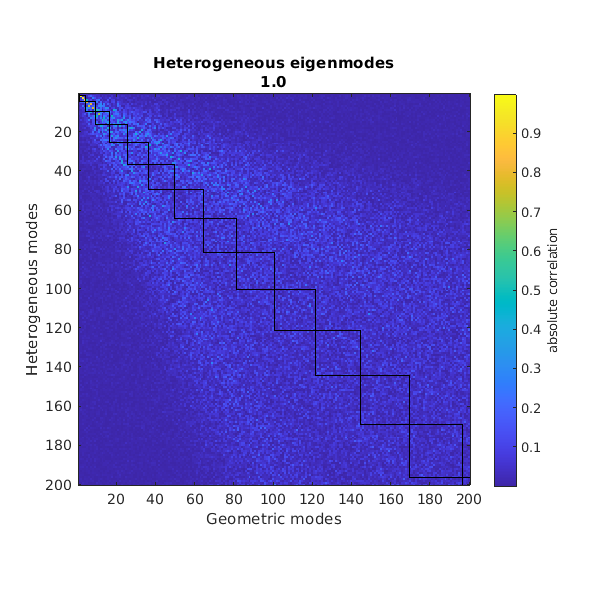

In [5]:
%% Correlate heterogeneous modes with geometric modes
if nBasisSets > 4
    nRows = 2;
    nCols = ceil(nBasisSets/2);
    figure('Position', [200, 0, 600*nCols, 600*nRows], 'visible', 'on')
else
    nRows = 1;
    nCols = nBasisSets;
    figure('Position', [200, 0, 600*nBasisSets, 600], 'visible', 'on');
end

for ii=1:nBasisSets
    if reorder
        % Reorder modes
        [~, ~, ~, newCorrs] = matchModes(heteroModes(:, :, ii), geomModes, 'showFigures', false, 'withinGroups', withinGroups);
        currentCorrs = newCorrs;
    else
        currentCorrs = corr(heteroModes(:, :, ii), geomModes);
    end
    
    % Plot matrix as heatmap
    subplot(nRows, nCols, ii)

    imagesc(abs(currentCorrs));
    axis square;
    cbar = colorbar; ylabel(cbar, "absolute correlation");
    xticks(0:20:200); yticks(0:20:200);
    xlabel('Geometric modes'); ylabel('Heterogeneous modes');
    title({'Heterogeneous eigenmodes'; basisSetLabels(ii)})
    % Plot box around eigengroups
    for jj = 1:ceil(sqrt(size(currentCorrs, 1))) % xline(ii^2 + 0.5);  yline(ii^2 + 0.5);
        rectangle('Position', [(jj-1)^2+0.5, (jj-1)^2+0.5, 2*jj-1, 2*jj-1]);
    end
end

% Save figure
% savecf(sprintf("%s/results/hetero-%s_surf-%s_reorder-%s_scale-%s_alpha-%s_method-%s_corrs", ...
%     projDir, heteroText, surf, reorderText, scaleText, alphaText, methodText), ".png", 300)

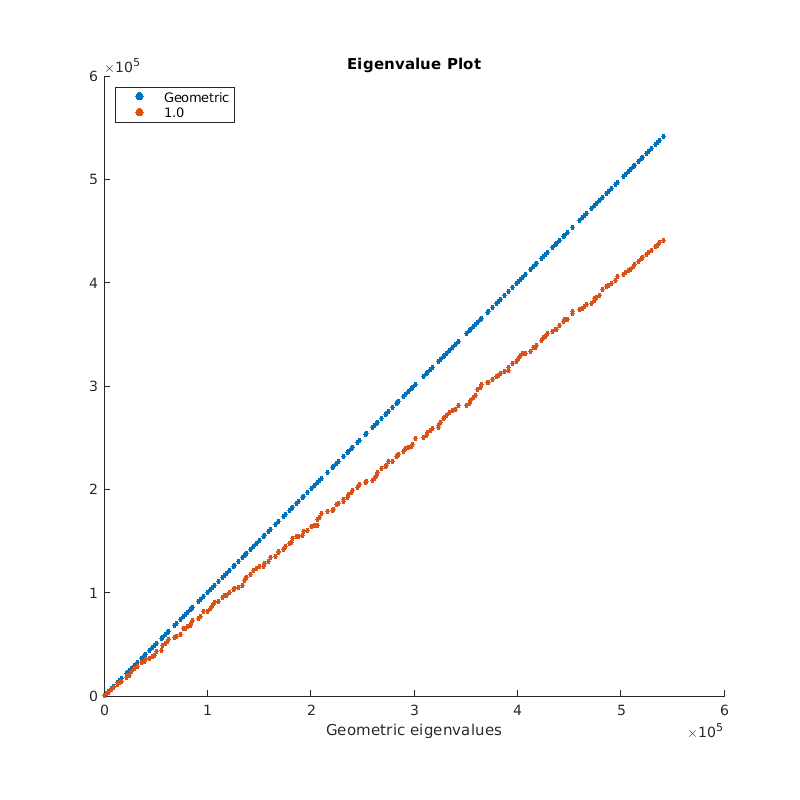

Unrecognized function or variable 'methodText'.

In [6]:
%% Eigenvalue plot

% Plot
figure('Position', [0, 0, 800, 800]);
pointSize = 12;

% Plot geometric eigvenvalues against itself
scatter(geomEvals, geomEvals, pointSize, "filled")
xlabel("Geometric eigenvalues")
title("Eigenvalue Plot")
axis('square')
legend("Geometric")
hold on

legendNames = cell(1, nBasisSets);
% Plot heterogeneous eigenvalues against geometric
for ii=1:nBasisSets
    scatter(geomEvals, heteroEvals(ii, :), pointSize, "filled")
    legendNames{ii} = basisSetLabels(ii);
    hold on
end

% set(gca, "YScale", "log")
% xlim([0, 0.05])
% ylim([0, 0.05])
legend(["Geometric", legendNames], "location", "northwest")

savecf(sprintf("%s/results/hetero-%s_surf-%s_scale-%s_alpha-%s_method-%s_eigvalPlot", ...
    projDir, heteroText, surf, scaleText, alphaText, methodText), ".png", 300)

In [ ]:
%% Correlate new heterogeneous modes with old heterogeneous modes (using wrong wave equation)

% Load old hetero modes
heteroDesc_old = 'hetero-%s_atlas-%s_space-%s_den-%s_surf-%s_hemi-%s_n-%i_scale-%s_alpha-%s_method-%s_maskMed-True';
heteroModes_old = zeros([size(geomModes), nBasisSets]);
heteroEvals_old = zeros(nBasisSets, nModes);
for ii=1:nBasisSets  
    heteroModes_old(:, :, ii) = dlmread(fullfile(emodeDir, "wrong_wave_equation", sprintf(heteroDesc_old, heteroLabel, atlas, ...
        space, den, surf, hemi, nModes, scale, alphaVals(ii), "modMass") + "_emodes.txt")); 
    heteroEvals_old(ii, :) = dlmread(fullfile(emodeDir, "wrong_wave_equation", sprintf(heteroDesc_old, heteroLabel, atlas, space, ...
        den, surf, hemi, nModes, scale, alphaVals(ii), "modMass") + "_evals.txt")); 
end

if nBasisSets > 4
    nRows = 2;
    nCols = ceil(nBasisSets/2);
    figure('Position', [200, 0, 600*nCols, 600*nRows], 'visible', 'on')
else
    nRows = 1;
    nCols = nBasisSets;
    figure('Position', [200, 0, 600*nBasisSets, 600], 'visible', 'on');
end

for ii=1:nBasisSets
    if reorder
        % Reorder modes
        [~, ~, ~, newCorrs] = matchModes(heteroModes(:, :, ii), heteroModes_old(:, :, ii), 'showFigures', false, 'withinGroups', withinGroups);
        currentCorrs = newCorrs;
    else
        currentCorrs = corr(heteroModes(:, :, ii), heteroModes_old(:, :, ii));
    end
    
    % Plot matrix as heatmap
    subplot(nRows, nCols, ii)

    imagesc(abs(currentCorrs));
    axis square;
    cbar = colorbar; ylabel(cbar, "absolute correlation");
    xticks(0:20:200); yticks(0:20:200);
    xlabel('Old Heterogeneous modes'); ylabel('Heterogeneous modes');
    title({'Heterogeneous eigenmodes'; basisSetLabels(ii)})
    % Plot box around eigengroups
    for jj = 1:ceil(sqrt(size(currentCorrs, 1))) % xline(ii^2 + 0.5);  yline(ii^2 + 0.5);
        rectangle('Position', [(jj-1)^2+0.5, (jj-1)^2+0.5, 2*jj-1, 2*jj-1]);
    end
end